# INTRODUCTION
Machine Learning (ML) is a subset of artificial intelligence (AI) that enables systems to learn from data, identify patterns, and make decisions or predictions without explicit programming

- Supervised Learning: The most common type, where the model is trained on labeled data. You provide it with both the input and the correct answer (like images of cats labeled "cat"). It learns to map inputs to outputs so it can predict labels for new, unseen data.

  **Examples**: Spam detection in emails, predicting house prices, and medical diagnosis.
- Unsupervised Learning: The model works with unlabeled data. There is no "answer key." Instead, the algorithm finds hidden patterns, groupings, or structures on its own.

  **Examples**: Grouping customers with similar shopping habits (clustering) or identifying unusual bank transactions (anomaly detection).
- Reinforcement Learning: This is "learning by doing" through trial and error. An "agent" interacts with an environment and receives rewards for good actions and penalties for bad ones, slowly learning the best strategy to maximize its total reward.
  **Examples**: Training robots to walk, teaching AI to play video games, and autonomous driving.

### Hybrid Types:
- Semi-Supervised Learning: Uses a small amount of labeled data and a large amount of unlabeled data to save time and cost on manual labeling.
- Self-Supervised Learning: The model generates its own labels from the data (like hiding words in a sentence and trying to predict them), which is the foundation for modern Large Language Models like ChatGPT

In [24]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mlxtend.plotting import plot_confusion_matrix, plot_decision_regions

In [2]:
# load dataset
df = pd.read_csv("/content/placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [3]:
# collect info
df.info()

#shape of the data
print("\n The shape of the data is :")
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB

 The shape of the data is :


(100, 4)

In [4]:
# check missing values
df.isnull().sum()

,0
Unnamed: 0,0
cgpa,0
iq,0
placement,0


In [5]:
# remove unknown column
df.drop(columns = ['Unnamed: 0'], inplace = True)

df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
# check duplicates
df.duplicated().sum()

np.int64(0)

# Steps we follow:
- preprocess + EDA + Feature Selection
- Scale the value
- Train-test split
- Train the model
- Evaluate the model/model selection
- deploy the model

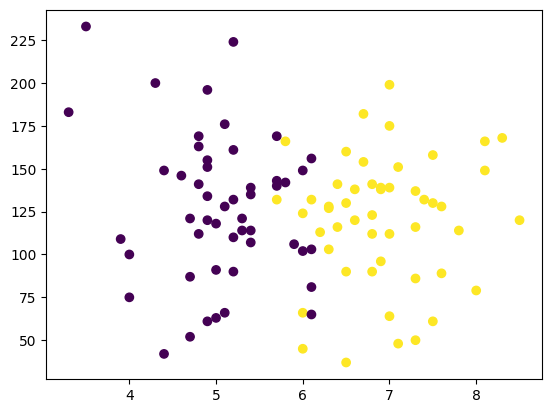

In [7]:
plt.scatter(df['cgpa'], df['iq'], c = df['placement'])

Logistic Regression

here, data seperates into two parts..! (placed or not)


In [8]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

In [9]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [10]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


train_test_split = (independent variable, dependent variable, test_size)

In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1)

In [12]:
X_train

,cgpa,iq
43,6.8,141.0
19,5.2,132.0
97,6.7,182.0
58,8.0,79.0
93,6.8,112.0
...,...,...
92,5.2,110.0
63,6.3,128.0
81,5.4,107.0
69,8.5,120.0


In [13]:
Y_train

,placement
43,1
19,0
97,1
58,1
93,1
...,...
92,0
63,1
81,0
69,1


In [14]:
X_test

,cgpa,iq
90,7.3,86.0
77,7.3,50.0
55,7.8,114.0
22,4.9,120.0
4,5.8,142.0
79,6.5,90.0
73,4.9,61.0
8,6.1,156.0
18,4.0,100.0
98,6.3,103.0


In [15]:
Y_test

,placement
90,1
77,1
55,1
22,0
4,0
79,1
73,0
8,0
18,0
98,1


In [16]:
scaler = StandardScaler()

In [17]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
clf = LogisticRegression()

In [19]:
# Model Training
clf.fit(X_train,Y_train)

LogisticRegression()

In [20]:
y_pred = clf.predict(X_test)

In [21]:
Y_test

,placement
90,1
77,1
55,1
22,0
4,0
79,1
73,0
8,0
18,0
98,1


In [22]:
accuracy_score(Y_test,y_pred)

0.9

<Axes: >

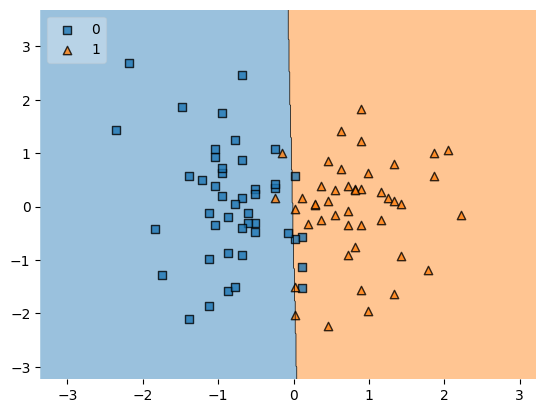

In [23]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [25]:
pickle.dump(clf,open('model.pkl','wb'))